In [2]:
# Load Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [4]:
file_path = '../data/raw/complaints.csv'
chunk_size = 100_000  # Tweak this based on RAM

# Create an iterator of chunks
chunks = pd.read_csv(
    file_path,
    chunksize=100_000,
    on_bad_lines="skip",  # SKIP problematic rows
    encoding="utf-8",      # or try "latin1" if utf-8 fails
    low_memory=False
)

# Iterate over chunks
for i, chunk in enumerate(chunks):
    print(f"Chunk {i} preview:")
    print(chunk.head())

    # Example: stop after first chunk just to test
    if i == 0:
        break


chunk.head()

Chunk 0 preview:
  Date received                                            Product  \
0    2025-06-20  Credit reporting or other personal consumer re...   
1    2025-06-20                                    Debt collection   
2    2025-06-20  Credit reporting or other personal consumer re...   
3    2025-06-20  Credit reporting or other personal consumer re...   
4    2025-06-20  Credit reporting or other personal consumer re...   

               Sub-product                                 Issue  \
0         Credit reporting  Incorrect information on your report   
1  Telecommunications debt     Attempts to collect debt not owed   
2         Credit reporting           Improper use of your report   
3         Credit reporting           Improper use of your report   
4         Credit reporting  Incorrect information on your report   

                                       Sub-issue Consumer complaint narrative  \
0            Information belongs to someone else                        

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


## Distribution of Complaints by Product

In [5]:
from collections import Counter

# Dictionary to count complaints per product
product_counter = Counter()

MAX_GOOD_CHUNK = 50  # or lower, test until it doesn't crash

for i, chunk in enumerate(chunks):
    if i >= MAX_GOOD_CHUNK:
        print(f"Stopping at chunk {i}")
        break

    # safe processing
    product_counts = chunk["Product"].dropna().value_counts()
    product_counter.update(product_counts.to_dict())



# Convert the Counter to a DataFrame for analysis and visualization
product_df = pd.DataFrame.from_dict(product_counter, orient='index', columns=['Complaint Count'])
product_df = product_df.sort_values(by='Complaint Count', ascending=False)

print(product_df)


Stopping at chunk 50
                                                    Complaint Count
Credit reporting or other personal consumer rep...          3390591
Credit reporting, credit repair services, or ot...           807625
Debt collection                                              278781
Checking or savings account                                  117274
Credit card                                                   85878
Money transfer, virtual currency, or money service            84386
Mortgage                                                      69292
Credit card or prepaid card                                   57533
Student loan                                                  33065
Vehicle loan or lease                                         28535
Credit reporting                                              12307
Payday loan, title loan, personal loan, or adva...             9449
Payday loan, title loan, or personal loan                      7709
Prepaid card               

## Word Count Analysis of Narratives

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\3723495784.py:9: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip')):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\3723495784.py:9: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip')):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\3723495784.py:9: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip')):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\3723495784.py:9: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, c

Stopped after collecting 50 clean chunks.
📊 Word Count Summary:
Total narratives: 1422646
Min words     : 1
Max words     : 6469
Median        : 112.0
Mean          : 172.39
Std Dev       : 222.16
Very short (<10 words) narratives: 7581
Very long (>500 words) narratives: 68774


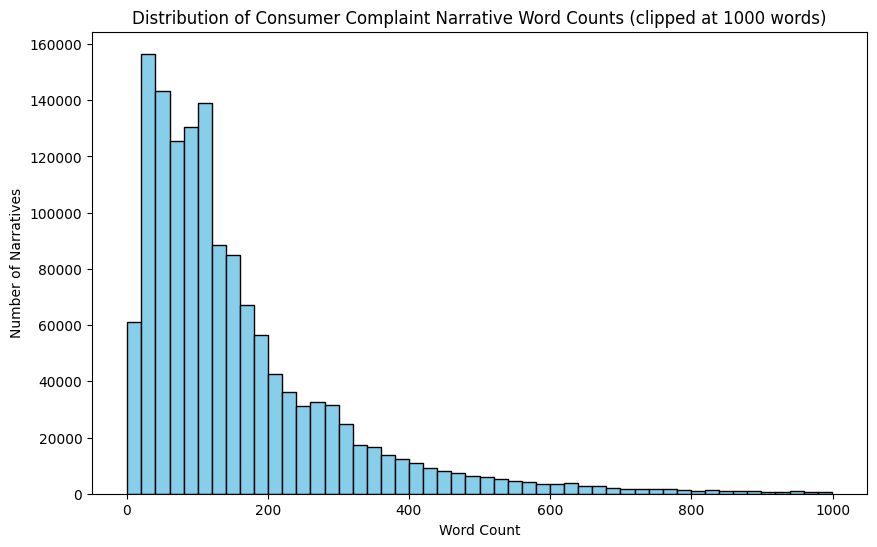

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

word_counts = []
MAX_GOOD_CHUNK = 50
SAFE_CHUNKS = 0

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip')):
    if SAFE_CHUNKS >= MAX_GOOD_CHUNK:
        print(f"Stopped after collecting {MAX_GOOD_CHUNK} clean chunks.")
        break

    try:
        narratives = chunk["Consumer complaint narrative"].dropna()
        word_counts.extend(narratives.apply(lambda x: len(x.split())))
        SAFE_CHUNKS += 1

    except Exception as e:
        print(f"⚠️ Skipped chunk {i} due to error: {e}")

# Convert list to numpy array for stats
word_counts_np = np.array(word_counts)

# Print summary stats instead of full list
print("📊 Word Count Summary:")
print(f"Total narratives: {len(word_counts_np)}")
print(f"Min words     : {word_counts_np.min()}")
print(f"Max words     : {word_counts_np.max()}")
print(f"Median        : {np.median(word_counts_np)}")
print(f"Mean          : {word_counts_np.mean():.2f}")
print(f"Std Dev       : {word_counts_np.std():.2f}")
print(f"Very short (<10 words) narratives: {(word_counts_np < 10).sum()}")
print(f"Very long (>500 words) narratives: {(word_counts_np > 500).sum()}")

# Plot histogram, clip outliers for better view
plt.figure(figsize=(10,6))
plt.hist(word_counts_np[word_counts_np < 1000], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Consumer Complaint Narrative Word Counts (clipped at 1000 words)')
plt.xlabel('Word Count')
plt.ylabel('Number of Narratives')
plt.show()


## complaints with and without narratives

In [12]:
with_narrative = 0
without_narrative = 0
MAX_GOOD_CHUNK = 50
SAFE_CHUNKS = 0

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip')):
    if SAFE_CHUNKS >= MAX_GOOD_CHUNK:
        print(f"Stopped after processing {MAX_GOOD_CHUNK} chunks.")
        break

    narratives = chunk["Consumer complaint narrative"]
    with_narrative += narratives.dropna().shape[0]
    without_narrative += narratives.isna().sum()
    SAFE_CHUNKS += 1

print(f"Complaints WITH narrative: {with_narrative}")
print(f"Complaints WITHOUT narrative: {without_narrative}")


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\346271760.py:6: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip')):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\346271760.py:6: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip')):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\346271760.py:6: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=100000, on_bad_lines='skip')):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\346271760.py:6: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunk

Stopped after processing 50 chunks.
Complaints WITH narrative: 1422646
Complaints WITHOUT narrative: 3577354


## cleaning and filtering 

In [17]:
import pandas as pd
import re
import os

# File path to raw data
file_path = "../data/raw/complaints.csv"  # <-- update to your actual file
output_path = "../data/processed/filtered_complaints.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Define keyword-based matching targets
target_keywords = [
    "credit card",
    "personal loan",
    "buy now pay later",
    "savings account",
    "money transfer"
]

# Normalize text filter function
def contains_target_keywords(text):
    text = str(text).lower()
    return any(keyword in text for keyword in target_keywords)

# Complaint cleaner
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

# Constants
CHUNK_SIZE = 100_000
MAX_CHUNKS = 10
SAFE_CHUNKS = 0

# Remove old output if exists
if os.path.exists(output_path):
    os.remove(output_path)

# Process in chunks
for i, chunk in enumerate(pd.read_csv(file_path, chunksize=CHUNK_SIZE, on_bad_lines="skip")):
    if SAFE_CHUNKS >= MAX_CHUNKS:
        print(f"⛔ Done. Processed max {MAX_CHUNKS} chunks.")
        break

    try:
        # Apply keyword matching
        filtered = chunk[
            chunk["Consumer complaint narrative"].notna() &
            chunk["Consumer complaint narrative"].str.strip().ne("") &
            (
                chunk["Product"].apply(contains_target_keywords) |
                chunk["Sub-product"].apply(contains_target_keywords)
            )
        ].copy()

        if filtered.empty:
            continue

        # Clean narrative text
        filtered["Cleaned Narrative"] = filtered["Consumer complaint narrative"].apply(clean_text)

        # Save
        mode = "w" if SAFE_CHUNKS == 0 else "a"
        header = SAFE_CHUNKS == 0
        filtered.to_csv(output_path, mode=mode, index=False, header=header)

        print(f"✅ Saved chunk {i} with {len(filtered)} rows")
        SAFE_CHUNKS += 1

    except Exception as e:
        print(f"⚠️ Skipping chunk {i} due to error: {e}")

print(f"\n🎯 Done. Final dataset saved to: {output_path}")


✅ Saved chunk 0 with 461 rows


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\3977155542.py:40: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=CHUNK_SIZE, on_bad_lines="skip")):


✅ Saved chunk 1 with 563 rows


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\3977155542.py:40: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=CHUNK_SIZE, on_bad_lines="skip")):


✅ Saved chunk 2 with 608 rows
✅ Saved chunk 3 with 790 rows


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\3977155542.py:40: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=CHUNK_SIZE, on_bad_lines="skip")):


✅ Saved chunk 4 with 1193 rows


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7988\3977155542.py:40: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(pd.read_csv(file_path, chunksize=CHUNK_SIZE, on_bad_lines="skip")):


✅ Saved chunk 5 with 1826 rows
✅ Saved chunk 6 with 2045 rows
✅ Saved chunk 7 with 3759 rows
✅ Saved chunk 8 with 6295 rows
✅ Saved chunk 9 with 4108 rows
⛔ Done. Processed max 10 chunks.

🎯 Done. Final dataset saved to: ../data/processed/filtered_complaints.csv


In [3]:
import pandas as pd

# Setup
file_path = "../data/raw/complaints.csv"
target_products = {
    "Credit card",
    "Personal loan",
    "Buy Now, Pay Later (BNPL)",
    "Savings account",
    "Money transfers"
}

# Chunk settings
chunk_size = 100000
MAX_GOOD_CHUNK = 50
SAFE_CHUNKS = 0

# Collect filtered chunks
filtered_chunks = []

for chunk in pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip'):
    if SAFE_CHUNKS >= MAX_GOOD_CHUNK:
        break

    # Drop empty narratives (NaN or blank string)
    chunk = chunk.dropna(subset=["Consumer complaint narrative"])
    chunk = chunk[chunk["Consumer complaint narrative"].str.strip() != ""]

    # Filter by product
    chunk = chunk[chunk["Product"].isin(target_products)]

    # Append result
    filtered_chunks.append(chunk)
    SAFE_CHUNKS += 1

# Combine all filtered chunks into one DataFrame
filtered = pd.concat(filtered_chunks, ignore_index=True)
filtered.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7112\3534103278.py:21: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip'):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7112\3534103278.py:21: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip'):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7112\3534103278.py:21: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip'):
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7112\3534103278.py:21: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121
1,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085
2,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217
3,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411
4,2025-06-09,Credit card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,"Although the account had been deemed closed, I...",Company believes it acted appropriately as aut...,Atlanticus Services Corporation,NY,11212,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13965746


In [4]:
filtered.head(10)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121
1,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085
2,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217
3,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411
4,2025-06-09,Credit card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,"Although the account had been deemed closed, I...",Company believes it acted appropriately as aut...,Atlanticus Services Corporation,NY,11212,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13965746
5,2025-06-11,Credit card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,I was trying to log into my account and it wou...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,XXXXX,NaN,Consent provided,Web,2025-06-11,Closed with explanation,Yes,NaN,14025020
6,2025-06-07,Credit card,Store credit card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,I received an email in XXXX from my XXXX XXXX ...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",CO,80128,Servicemember,Consent provided,Web,2025-06-07,Closed with monetary relief,Yes,NaN,13950990
7,2025-06-06,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,"I filed a dispute with my bank, Truist, on my ...",Company has responded to the consumer and the ...,TRUIST FINANCIAL CORPORATION,FL,33607,NaN,Consent provided,Web,2025-06-06,Closed with explanation,Yes,NaN,13938213
8,2025-06-10,Credit card,Store credit card,Trouble using your card,Can't use card to make purchases,"Ongoing payment situation with Best Buy, my pa...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",MA,01108,Older American,Consent provided,Web,2025-06-10,Closed with explanation,Yes,NaN,14001321
9,2025-03-24,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Overcharged for something you did purchase wit...,I just had the worst experience ever with thei...,NaN,CAPITAL ONE FINANCIAL CORPORATION,UT,84660,NaN,Consent provided,Web,2025-03-24,Closed with explanation,Yes,NaN,12629540


## cleaning 

In [5]:
import pandas as pd
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # Remove special chars
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra whitespace
    # Optional: remove common boilerplate phrases
    boilerplate_patterns = [
        r"i am writing to file a complaint",
        r"i am writing to report",
        r"this is a complaint",
        r"i want to file a complaint",
        r"i'm submitting this complaint",
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)
    return text

# Apply cleaning to the filtered DataFrame
filtered["Consumer complaint narrative"] = filtered["Consumer complaint narrative"].apply(clean_text)

# Save cleaned version
filtered.to_csv("../data/processed/filtered_complaints.csv", index=False)
